#Assignment 4: Neural Nets and Reinforcement Learning

In this assignment, you will:


*   Use ```Pandas``` to load and inspect data
*   Use tools from ```sklearn``` to pre-process data for training and testing
*   Code your own implementation of two RL algorithms and compare performance
*   Use tools from ```sklearn``` to train a neural network to classify handwritten digits
*   Tune hyperparameters of your neural network
*   Add text cells with writeup with your answers (indicated throughout the assignment)

**If you used AI to complete this assignment, edit this text box to include the tool used.**

I used the following AI tool to complete this assignment (leave blank if none):

Additional questions: were there any mistakes that the AI made that you had to correct? If so, list one example.

# Part 1: On-Policy vs Off-Policy RL

For part one of this assignment, you will compare the performance of two RL algorithms. You have learned the Q-learning update rule (note the difference from the in-class Q-learning update: $Q(S_t, A_t)$ on the right-hand side is not multiplied by $1-\alpha$. This is just a slightly different formulation, but $\alpha$ still signifies the weight given to new information):

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \Big].
$$

This update is what is known as *off-policy* because it is updated by $\max_{a} Q(S_{t+1}, a)$, not necessarily the action taken.

There is another algorithm, SARSA (**S**tate-**A**ction-**R**eward-**S**tate-**A**ction) that uses the following update rule:

$$
Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \Big[ R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \Big].
$$

SARSA is an *on-policy* algorithm because it is updated using the action actually taken.

In this first part, you will implement the Q-learning and SARSA updates/actions using the ```numpy``` and [```random```](https://docs.python.org/3/library/random.html) libraries). We provide a gridworld for a reinforcement learning agent. In this problem, you have been assigned to plan a path for a shipping freight to take from its start location to destination. Most of the water is navigable, but some areas are dangerous. We represent the environment as a $5 \times 5$ grid, where each grid entry is a location the shipping freight can be in. We will define the following about the environment:

* State representation: ($x_1, x_2$), where the shipping freight is in row $x_1$ and column $x_2$.
* ```START_LOCATION = (4,0)```: the shipping freight starts in grid location (4,0)
* ```DESTINATION = (2,4)```: the shipping freight's destination is in grid location (2,4)
* ```DANGER_LOCATIONS = [(4,1), (4,2), (4,3), (3,1), (3,2)]```: the locations of dangerous areas of water
* **Actions**: up, right, left, down (no diagonal movements). If the agent attempts to make an illegal step (leaving the grid), the agent will not move.
* **Rewards**: -1 living reward, -100 for stepping into a danger area, and +100 for reaching the destination
* **Terminal states**: Danger areas, destination

We provide the code for this environment and a visualization below. You will not need to edit this code, but reading through and understanding it will help you code Q-Learning and understand the results.

In [ ]:
GRID_ROWS = 5
GRID_COLS = 5

START_LOCATION = (4, 0)  # Row, Column
DESTINATION = (2, 4)     # Row, Column

DANGER_LOCATIONS = [
    (4, 1), (4, 2), (4, 3), # Example danger locations
    (3, 1), (3, 2)
]

REWARD_DESTINATION = 100
PENALTY_DANGER = -100
PENALTY_STEP = -1

print(f"Grid Dimensions: {GRID_ROWS} rows, {GRID_COLS} columns")
print(f"Start Location (Depot): {START_LOCATION}")
print(f"Destination (Delivery Point): {DESTINATION}")
print(f"Danger Locations: {DANGER_LOCATIONS}")
print(f"Reward for Destination: {REWARD_DESTINATION}")
print(f"Penalty for Danger: {PENALTY_DANGER}")
print(f"Penalty for Normal Step: {PENALTY_STEP}")

In [ ]:
class CargoRoutingEnv:
    def __init__(self, grid_rows, grid_cols, start_location, destination, danger_locations, reward_destination, penalty_danger, penalty_step):
        self.grid_rows = grid_rows
        self.grid_cols = grid_cols
        self.start_location = start_location
        self.destination = destination
        self.danger_locations = danger_locations
        self.reward_destination = reward_destination
        self.penalty_danger = penalty_danger
        self.penalty_step = penalty_step

        self.current_position = start_location
        self.done = False

        self.action_space = {
            'UP': (-1, 0),
            'DOWN': (1, 0),
            'LEFT': (0, -1),
            'RIGHT': (0, 1)
        }
        print("CargoRoutingEnv initialized with parameters.")

    def reset(self):
        self.current_position = self.start_location
        self.done = False
        print(f"Environment reset. Current position: {self.current_position}")
        return self.current_position

    def step(self, action):
        if self.done:
            print("Episode already terminated. Reset the environment.")
            return self.current_position, 0, True

        row, col = self.current_position
        dr, dc = self.action_space.get(action, (0, 0)) # Default to no movement if action is invalid

        new_row, new_col = row + dr, col + dc

        reward = 0
        terminated = False

        # Check for boundary conditions
        if not (0 <= new_row < self.grid_rows and 0 <= new_col < self.grid_cols):
            # Agent hits boundary, doesn't move, incurs penalty_step
            reward = self.penalty_step
            print(f"Action '{action}' hit boundary. Position unchanged: {self.current_position}, Reward: {reward}")
            return self.current_position, reward, terminated # Position remains unchanged

        self.current_position = (new_row, new_col)

        # Determine reward and termination status
        if self.current_position == self.destination:
            reward = self.reward_destination
            terminated = True
            print(f"Reached destination! Position: {self.current_position}, Reward: {reward}")
        elif self.current_position in self.danger_locations:
            reward = self.penalty_danger
            terminated = True
            print(f"Steered into danger! Position: {self.current_position}, Reward: {reward}")
        else:
            reward = self.penalty_step
            print(f"Took a normal step. Position: {self.current_position}, Reward: {reward}")

        self.done = terminated
        return self.current_position, reward, terminated


In [ ]:
def visualize_grid(grid_rows, grid_cols, start, destination, danger):
    grid_map = []
    for r in range(grid_rows):
        row_str = []
        for c in range(grid_cols):
            if (r, c) == start:
                row_str.append('S') # Start location
            elif (r, c) == destination:
                row_str.append('D') # Destination
            elif (r, c) in danger:
                row_str.append('!') # Danger
            else:
                row_str.append('.') # Empty path
        grid_map.append(' '.join(row_str))
    return '\n'.join(grid_map)

# Get the parameters from the previously defined constants
# (Ensure these are defined in your current kernel session)

# Print the ASCII representation
print("\n--- Cargo Routing Grid Map ---")
print(visualize_grid(GRID_ROWS, GRID_COLS, START_LOCATION, DESTINATION, DANGER_LOCATIONS))
print("S: Start, D: Destination, !: Danger, .: Open Water")

1. **Implement Q-learning** (30 points)

1(a) (20 points). In the following code blocks, fill in the missing lines of code to complete the Q-learning algorithm as described in class. You only need to fill in lines marked with ```# TODO```, but you should understand the code. Keep the default parameters as given. Usually, you would need to perform hyperparameter optimization for $\alpha, \gamma, \epsilon$, and the rate at which $\epsilon$ decays, but for the purposes of this homework we'll provide you with settings that perform reasonably well: $\alpha = 0.01$, $\gamma = 0.95$, $\epsilon=0.9$ with a decay rate of 0.001.

In [ ]:
import numpy as np

# 1. Determine the size of the state space
num_states = ... # TODO

# 2. Determine the size of the action space
actions = ['UP', 'DOWN', 'LEFT', 'RIGHT']
num_actions = len(actions)

# Create a mapping from (row, col) state to a single integer index
def state_to_index(row, col, grid_cols):
    return row * grid_cols + col

# Create a mapping from action name to an integer index
# This means that 0 maps to UP, 1 to DOWN, 2 to LEFT, and 3 to RIGHT
action_to_index = {action: i for i, action in enumerate(actions)}

# 3. Initialize the Q-table
# The Q-table will store Q-values for each (state, action) pair.
# Each state is represented by an integer from 0 to num_states-1.
# Each action is represented by an integer from 0 to num_actions-1.
# The q_table should be initialized as an array of all zeros with shape (num_states, num_actions)
q_table = ... # TODO

# 4. Define Q-learning parameters
alpha = 0.1   # Learning rate
gamma = 0.95  # Discount factor
epsilon = 0.9 # Exploration rate (starts high for exploration)

print(f"Q-learning parameters initialized: alpha={alpha}, gamma={gamma}, epsilon={epsilon}")

In [ ]:
import random

# Helper function to map (row, col) state to a single integer index
def state_to_index(row, col, grid_cols):
    return row * grid_cols + col

# Helper function to map integer index back to (row, col) state
def index_to_state(idx, grid_cols):
    row = idx // grid_cols
    col = idx % grid_cols
    return (row, col)

# 1. Epsilon-greedy policy function
def choose_action(state, q_table, actions_list, epsilon, grid_cols):
    # Map current (row, col) state to its integer index
    state_idx = state_to_index(state[0], state[1], grid_cols)

    # The below code (setting action_idx and action_name) shows how to select action_name, action_idx greedily.
    # You can use this code in your epsilon-greedy implementation
    # You can use random.uniform(0,1) to find a random number between 0 and 1 (if that number is < epsilon, make one decision)
    # You can use random.choice(A) to select a random item from a list A

    action_idx = np.argmax(q_table[state_idx, :]) # Gets the maximum q-value from the q-table for the current state index
    action_name = actions_list[action_idx] # Converts the actions back to named form (UP, DOWN, LEFT, RIGHT)

    # TODO: Implement epsilon-greedy action selection. Remove lines above when done.

    return action_name, action_idx

In [ ]:
def update_q_table(q_table, current_state, action_idx, reward, next_state, terminated, alpha, gamma, grid_cols):
    current_state_idx = state_to_index(current_state[0], current_state[1], grid_cols)

    # Map next state to its integer index
    if next_state is not None: # If not terminal state
        next_state_idx = state_to_index(next_state[0], next_state[1], grid_cols)
    else:
        next_state_idx = None # Should only happen if terminated is True

    # TODO: implement Q-learning update rule
    # Q-learning update rule

    if terminated:
        # If the episode terminated, there is no next state to consider for future rewards.
        # To compensate, remove gamma*max(Q(s,a)) from the update rule
        q_table[current_state_idx, action_idx] = ... # TODO
    else:
        # If the episode is not terminated
        q_table[current_state_idx, action_idx] = ... # TODO

    return q_table

1(b) (10 points). Fill in the TODOs below to run your Q-learning implementation for 10000 episodes on the shipping freight problem. You will only let Q-learning run for up to 200 steps per episode, and you will decay $\epsilon$ by 0.001 each episode (without letting $\epsilon$ go below 0.01).

In [ ]:
num_episodes = 10000 # Total number of training episodes
max_steps_per_episode = 200 # Maximum steps per episode to prevent infinite loops

# Initialize the environment
env = CargoRoutingEnv(
    GRID_ROWS, GRID_COLS, START_LOCATION, DESTINATION,
    DANGER_LOCATIONS, REWARD_DESTINATION, PENALTY_DANGER, PENALTY_STEP
)

epsilon_decay_rate = 0.001 # Rate at which epsilon decays after each episode
min_epsilon = 0.01 # Minimum exploration rate

# Keep track of the total sum of rewards received per episode
# i.e. the first entry should be the total reward received in the first episode, the second is the total reward received in the second episode, etc
rewards_per_episode = []

print("Starting Q-learning training...")

for episode in range(num_episodes):
    # Reset the environment for a new episode
    current_state = env.reset()
    # The agent has just started, so it is not in a terminal state
    done = False
    # Keep track of the total reward over this episode
    episode_reward = 0

    for step in range(max_steps_per_episode):
        # Use the epsilon-greedy policy to select an action
        # Use the choose_action function you implemented
        action_name, action_idx = ... # TODO

        # Take the chosen action in the environment
        # The step() method defined in the environment will take an action for you, and return the next state, the reward, and whether the agent is in a terminal state
        next_state, reward, done = ... # TODO

        # Apply the Q-learning update rule using update_q_table
        q_table = ... # TODO

        # Update the current state and keep track of total reward (sum of rewards, not discounted)
        current_state = next_state
        episode_reward = ... # TODO

        # Break the loop if the episode terminates
        if done:
            break

    # Decay epsilon after each episode (exploration-exploitation trade-off)
    # This line should subtract the decay rate from epsilon, but not let epsilon go below the min_epsilon
    epsilon = ... # TODO

    # Keep track of total episode reward
    rewards_per_episode.append(episode_reward)

    # Print out info about the agent/environment every 500 episodes
    if (episode + 1) % 500 == 0:
        print(f"Episode {episode + 1}/{num_episodes} - Total Reward: {episode_reward:.2f} - Epsilon: {epsilon:.4f}")

print("Q-learning training finished.")
print(f"Final Q-table shape: {q_table.shape}")

We provide code to visualize the optimal path obtained by Q-learning on the shipping freight task below. Run this code to see the Q-learning path.

In [ ]:
def get_optimal_path(q_table, grid_rows, grid_cols, start_location, destination, danger_locations, actions_list, max_steps):
    current_state = start_location
    optimal_path = [current_state]
    steps = 0

    while current_state != destination and current_state not in danger_locations and steps < max_steps:
        state_idx = state_to_index(current_state[0], current_state[1], grid_cols)

        # Select action with the maximum Q-value (greedy policy)
        action_idx = np.argmax(q_table[state_idx, :])
        action_name = actions_list[action_idx]

        # Determine next state using the environment's action mapping (simulated)
        # We need the action_space from the env, or recreate it
        action_map = {
            'UP': (-1, 0),
            'DOWN': (1, 0),
            'LEFT': (0, -1),
            'RIGHT': (0, 1)
        }

        dr, dc = action_map[action_name]
        new_row, new_col = current_state[0] + dr, current_state[1] + dc

        # Check for boundary conditions (similar to env.step)
        if not (0 <= new_row < grid_rows and 0 <= new_col < grid_cols):
            # If hit boundary, stay in current state
            next_state = current_state
        else:
            next_state = (new_row, new_col)

        if next_state not in optimal_path:
            optimal_path.append(next_state)
        current_state = next_state
        steps += 1

        # If we loop back to a previous state, it means it's stuck in a loop
        # Or if the path is too long without reaching destination/danger, break
        if len(optimal_path) > grid_rows * grid_cols * 2: # Heuristic to detect infinite loops
            break

    return optimal_path

print("Optimal path extraction function defined.")

optimal_path = get_optimal_path(
    q_table,
    GRID_ROWS, GRID_COLS,
    START_LOCATION, DESTINATION, DANGER_LOCATIONS,
    actions, # actions list defined earlier
    max_steps_per_episode
)

print(f"Learned Optimal Path: {optimal_path}")

def visualize_path_on_grid(grid_rows, grid_cols, start, destination, danger, path):
    grid_map = []
    for r in range(grid_rows):
        row_str = []
        for c in range(grid_cols):
            if (r, c) == start:
                row_str.append('S') # Start location
            elif (r, c) == destination:
                row_str.append('D') # Destination
            elif (r, c) in danger:
                row_str.append('!') # Danger
            elif (r, c) in path and (r,c) != start and (r,c) != destination:
                row_str.append('P') # Path
            else:
                row_str.append('.') # Empty path
        grid_map.append(' '.join(row_str))
    return '\n'.join(grid_map)

print("\n--- Learned Optimal Path on Grid ---")
print(visualize_path_on_grid(GRID_ROWS, GRID_COLS, START_LOCATION, DESTINATION, DANGER_LOCATIONS, optimal_path))
print("S: Start, D: Destination, !: Danger, P: Path, .: Open Water")

2. **Implement SARSA** (35 points)

2(a) (20 points) Fill in the TODOs in the following code to implement the SARSA algorithm.

In [ ]:
def update_sarsa_table(q_table, current_state, action_idx, reward, next_state, next_action_idx, terminated, alpha, gamma, grid_cols):
    current_state_idx = state_to_index(current_state[0], current_state[1], grid_cols)

    old_q_value = q_table[current_state_idx, action_idx]

    if terminated:
        # If the episode terminated, there is no next state to consider for future rewards.
        # To compensate, remove gamma*Q(s_{t+1},a_{t+1}) from the update rule
        q_table[current_state_idx, action_idx] = ... # TODO
    else:
        # SARSA update: use Q-value of the action taken in the next state
        # Note: you have access to next_state and next_action_idx as input to this function
        next_q_value = ... # TODO
        q_table[current_state_idx, action_idx] = ... # TODO

    return q_table

2(b) (15 points). Fill in the TODOs below to run your SARSA implementation for 10000 episodes on the shipping freight problem. You will only let SARSA run for up to 200 steps per episode, and you will decay $\epsilon$ by 0.001 each episode (without letting $\epsilon$ go below 0.01).

In [ ]:
num_episodes_sarsa = 10000
max_steps_per_episode_sarsa = 200

# Re-initialize Q-table for SARSA
q_table_sarsa = np.zeros((num_states, num_actions))

# Set hyperparameters
alpha = 0.01
gamma = 0.95

# Epsilon parameters for SARSA
epsilon_sarsa = 1.0 # Starting exploration rate
epsilon_decay_rate_sarsa = 0.001 # Rate at which epsilon decays
min_epsilon_sarsa = 0.01 # Minimum exploration rate

rewards_per_episode_sarsa = []

print("Starting SARSA training...")

for episode in range(num_episodes_sarsa):
    current_state = env.reset()
    done = False
    episode_reward = 0

    # Select initial action using epsilon-greedy policy
    action_name, action_idx = ... # TODO

    for step in range(max_steps_per_episode_sarsa):
        # Take the chosen action in the environment
        next_state, reward, done = ... # TODO

        # Choose the next action based on the *next actual state* (on-policy), not the max Q-value
        # Use the choose_action function you implemented
        if not done:
            next_action_name, next_action_idx = ... # TODO
        else:
            next_action_name, next_action_idx = None, None # No next action if terminated

        # Apply the SARSA update rule using update_sarsa_table
        q_table_sarsa = ... # TODO

        # Update current state and action
        current_state = next_state
        action_name = next_action_name
        action_idx = next_action_idx

        # Keep track of total reward (sum of rewards, not discounted)
        episode_reward = ... # TODO

        if done:
            break
    # Decay epsilon after each episode (exploration-exploitation trade-off)
    # This line should subtract the decay rate from epsilon, but not let epsilon go below the min_epsilon
    epsilon_sarsa = ... # TODO

    # Keep track of total episode reward
    rewards_per_episode_sarsa.append(episode_reward)

    # Print out info about the agent/environment every 500 episodes
    if (episode + 1) % 1000 == 0:
        print(f"  Episode {episode + 1}/{num_episodes_sarsa} - Total Reward: {episode_reward:.2f} - Epsilon: {epsilon_sarsa:.4f}")

print("SARSA training finished.")
print(f"Final SARSA Q-table shape: {q_table_sarsa.shape}")

Once again, we provide you with code to visualize the path learned by SARSA. Run this code to see the visualization.

In [ ]:
optimal_path_sarsa = get_optimal_path(
    q_table_sarsa,
    GRID_ROWS, GRID_COLS,
    START_LOCATION, DESTINATION, DANGER_LOCATIONS,
    actions,
    max_steps_per_episode_sarsa
)

print(f"Learned Optimal Path from SARSA: {optimal_path_sarsa}")

print("\n--- Learned Optimal Path from SARSA on Grid ---")
print(visualize_path_on_grid(GRID_ROWS, GRID_COLS, START_LOCATION, DESTINATION, DANGER_LOCATIONS, optimal_path_sarsa))
print("S: Start, D: Destination, !: Danger, P: Path, .: Open Water")

**Question**: how would you qualitatively describe the difference between the Q-learning and SARSA learned policies?

**Answer**:

**Question**: What about the update rule causes the two agents to learn different paths?

**Answer**:

**Question**: Why does SARSA end up with a lower total reward than Q-learning?

**Answer**:

3. **Changing behavior** (10 points)

Go back to the first code block where the rewards were defined. Change the rewards such that SARSA and Q-learning learn the same path (and both reach the destination)? Save the reward amounts and the shared optimal path in the code block below, and run our code to show the path. **Return rewards to initial settings before submitting your code**.

In [ ]:
# Settings that cause Q-learning and SARSA to behave the same on this problem

REWARD_DESTINATION_SETTING = ... # TODO
PENALTY_DANGER_SETTING = ... # TODO
PENALTY_STEP_SETTING = ... # TODO

# Shared Q-learning and SARSA optimal path
optimal_path = ... # TODO

**Question:** Why did this reward setting result in the same path?

**Answer:**

# Part 2: Neural Networks

In part two of this assignment, we'll introduce the first image data you'll work with in this certificate. You'll be using a neural network to

In future courses, you will be learning how to use libraries like PyTorch to code deep learning networks. PyTorch will take some time to learn, so for this assignment we'll continue to use sklearn, which luckily provides a neural network implementation called [```MLPClassifier```](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

We'll be using the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database), which consists of black and white images of handwritten digits. We [load the dataset from ```sklearn```](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) for you, so no data file/upload is needed. The ```sklearn``` version of this dataset has an 8x8 resolution (images are 8 pixels by 8 pixels). Each image is represented by a feature vector of length 64 (the number of pixels in each image), where the $i^{th}$ feature is a number from 0-15, representing a gray-scale from 0 (white) to 15 (black) of pixel $i$. An example image from ```sklearn``` is shown below: the "target" is the true label.

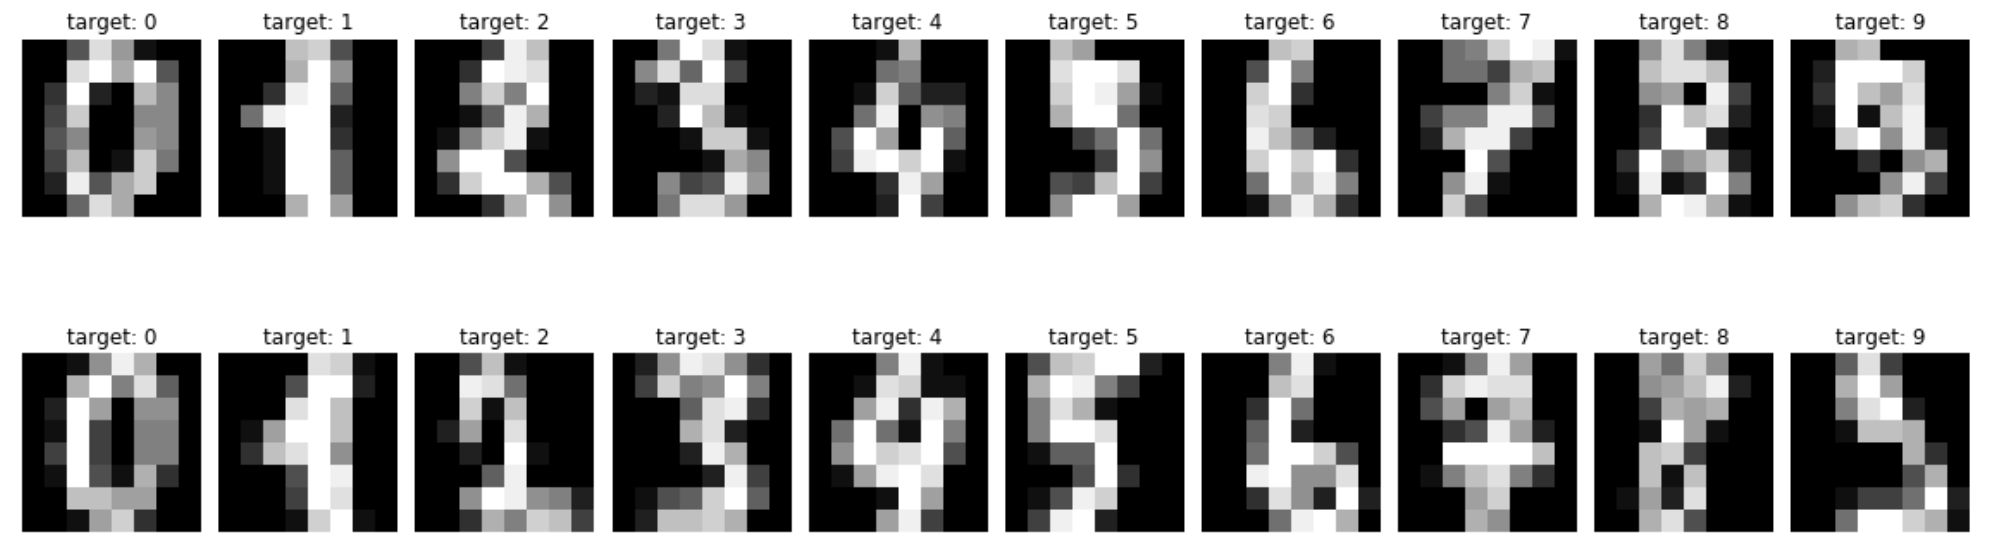


4. **Training a neural net** (25 points)

4(a) (5 points). Do the usual preprocessing: split the data into an $X$ and $y$ set, then split the data into training and testing. You do not need to standardize the data for this problem, as every feature is on the same scale.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

# Load the MNIST dataset from sklearn
mnist = load_digits()

# Separate input and labels
# You can use mnist.data and mnist.target for this, see documentation for details: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html
X = ... # TODO
y = ... # TODO

# Split the data into training (80%) and testing (20%) sets. Make sure to use random_state = 42.
X_train, X_test, y_train, y_test = ... # TODO


print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


4(b) (20 points) Use ```GridSearchCV``` (or ```HalvingGridSearchCV``` if training takes too long) to search over settings of the following hyperparameters for ```MLPClassifier```, optimizing for ```accuracy```:

* ```hidden_layer_sizes```: You can try up to 2 hidden layers, with as many neurons in each layer as you like. Example: to pass in 1 hidden layer with 10 neurons, set ```hidden_layer_sizes=(10,)```. For 2 hidden layers, the first with 100 neurons and the second with 15, set ```hidden_layer_sizes=(100,15)```.
* ```activation```: ```'relu'```, ```'tanh'```, or ```'logistic'```
* ```learning_rate_init```: The learning rate (usually small values, such as 0.0001, 0.001, 0.01, etc are good here)
* ```alpha```: the regularization weight. 0 sets this to no regularization.

**You can try whatever combinations of hyperparameters you want**. You do not have to try all combinations, and you can choose what settings to try. Your task for this question is to find hyperparameters that result in the highest accuracy you can find (must be **at least 97%** to get full credit, but you can optimize more!). After running GridSearchCV, run your classifier with the best hyperparameter settings to find the accuracy on the test set. You must use either ```GridSearchCV``` or ```HalvingGridSearchCV``` to find the hyperparameter settings.

It is ok to see ```ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.``` for this problem; we set ```max_iter=1000``` to ensure training can happen in a timely manner. You should still be able to find good solutions, but you can also increase the ```max_iter``` number if you don't mind training for longer.

Report the achieved accuracy below.


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

# Instantiate an MLPClassifier model with max_iter = 1000 and random_state=42
mlp = ... # TODO

# Define a hyperparameter grid for MLPClassifier
param_grid = ... # TODO

# Initialize GridSearchCV or HalvingGridSearchCV and fit to training data
# TODO

In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

# Get the best hyperparameters and train your neural net
# TODO

# Make predictions on the test set
y_pred = ... # TODO

# Evaluate the model's accuracy
accuracy = ... # TODO


**Question:** How did you pick which hyperparameters to try?

**Answer:**

**Question:** What was the highest accuracy you were able to achieve, and with what hyperparameter settings? There may some uncontrollable randomness here, so take a screenshot and attach the image to this text box.

**Answer:**

